# External Sampling MCCFR on Leduc Poker

This notebook uses Leduc Poker as the main experiment. Kuhn Poker is useful for debugging, but Leduc is large enough that the node-visit advantage of external-sampling MCCFR is visible.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
ROOT = cwd if (cwd / "src").exists() else cwd.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from cfr import VanillaCFR
from external_sampling_mccfr import ExternalSamplingMCCFR
from leduc_poker import LeducPoker
from util import collect_information_sets, expected_value, exploitability, format_strategy

FIG_DIR = ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

efg = LeducPoker.efg(max_raises=2)
actions, _ = collect_information_sets(efg)
print("Nodes:", len(efg))
print("Information sets:", len(actions))

Nodes: 9451
Information sets: 288


## Training Helpers

In [2]:
def run_cfr(checkpoints):
    trainer = VanillaCFR(efg)
    rows = []
    previous = 0
    start = time.perf_counter()

    for step in checkpoints:
        trainer.train(int(step - previous))
        previous = int(step)
        strategy = trainer.average_strategy()
        rows.append(
            {
                "algorithm": "CFR",
                "seed": 0,
                "iterations": trainer.iterations,
                "node_visits": trainer.node_visits,
                "seconds": time.perf_counter() - start,
                "value": expected_value(efg, strategy),
                "exploitability": exploitability(efg, strategy),
            }
        )

    return trainer, pd.DataFrame(rows)


def run_external_sampling(checkpoints, seeds):
    rows = []
    trainers = []

    for seed in seeds:
        trainer = ExternalSamplingMCCFR(efg, seed=seed)
        trainers.append(trainer)
        previous = 0
        start = time.perf_counter()

        for step in checkpoints:
            trainer.train(int(step - previous))
            previous = int(step)
            strategy = trainer.average_strategy()
            rows.append(
                {
                    "algorithm": "External Sampling MCCFR",
                    "seed": seed,
                    "iterations": trainer.iterations,
                    "node_visits": trainer.node_visits,
                    "seconds": time.perf_counter() - start,
                    "value": expected_value(efg, strategy),
                    "exploitability": exploitability(efg, strategy),
                }
            )

    return trainers, pd.DataFrame(rows)


def summarize(df):
    return (
        df.groupby(["algorithm", "iterations"], as_index=False)
        .agg(
            exploitability=("exploitability", "mean"),
            exploitability_std=("exploitability", "std"),
            value=("value", "mean"),
            node_visits=("node_visits", "mean"),
            seconds=("seconds", "mean"),
        )
        .fillna(0.0)
    )

## Run Experiments

In [3]:
cfr_checkpoints = np.unique(np.round(np.geomspace(1, 500, 14)).astype(int))
mccfr_checkpoints = np.unique(np.round(np.geomspace(100, 100_000, 18)).astype(int))
seeds = [0, 1, 2]

cfr_trainer, cfr_df = run_cfr(cfr_checkpoints)
mccfr_trainers, mccfr_df = run_external_sampling(mccfr_checkpoints, seeds)

results = pd.concat([cfr_df, mccfr_df], ignore_index=True)
summary = summarize(results)
summary.tail()

,algorithm,iterations,exploitability,exploitability_std,value,node_visits,seconds
27,External Sampling MCCFR,19684,0.123464,0.024700,-0.084873,8.243893e+05,3.418596
28,External Sampling MCCFR,29552,0.090673,0.006789,-0.085914,1.240812e+06,5.150035
29,External Sampling MCCFR,44367,0.068173,0.007715,-0.088158,1.876218e+06,7.716738
30,External Sampling MCCFR,66608,0.057810,0.008715,-0.087383,2.804351e+06,11.468647
31,External Sampling MCCFR,100000,0.041565,0.003011,-0.088230,4.226681e+06,17.338371


In [4]:
final = summary.sort_values(["algorithm", "iterations"]).groupby("algorithm").tail(1)
final[["algorithm", "iterations", "value", "exploitability", "node_visits", "seconds"]]

,algorithm,iterations,value,exploitability,node_visits,seconds
13,CFR,500,-0.09117,0.030586,9.451000e+06,15.792437
31,External Sampling MCCFR,100000,-0.08823,0.041565,4.226681e+06,17.338371


In [5]:
print("CFR nodes per iteration:", cfr_trainer.node_visits / cfr_trainer.iterations)
print("MCCFR nodes per iteration, seed 0:", mccfr_trainers[0].node_visits / mccfr_trainers[0].iterations)

print("\nSelected MCCFR average strategy entries, seed 0")
strategy = format_strategy(mccfr_trainers[0].average_strategy(), digits=3)
for info_set in list(strategy)[:8]:
    print(info_set, strategy[info_set])

CFR nodes per iteration: 18902.0
MCCFR nodes per iteration, seed 0: 42.63397

Selected MCCFR average strategy entries, seed 0
P0|card=J|pub=-|r=0|h0=-|h1=-|cur=- {'check': 0.927, 'bet': 0.073}
P0|card=J|pub=-|r=0|h0=bet.raise|h1=-|cur=bet.raise {'fold': 0.001, 'call': 0.999}
P0|card=J|pub=-|r=0|h0=check.bet|h1=-|cur=check.bet {'fold': 0.927, 'call': 0.054, 'raise': 0.02}
P0|card=J|pub=J|r=1|h0=bet.call|h1=-|cur=- {'check': 0.341, 'bet': 0.659}
P0|card=J|pub=J|r=1|h0=bet.call|h1=bet.raise|cur=bet.raise {'fold': 0.003, 'call': 0.997}
P0|card=J|pub=J|r=1|h0=bet.call|h1=check.bet|cur=check.bet {'fold': 0.0, 'call': 0.0, 'raise': 1.0}
P0|card=J|pub=J|r=1|h0=bet.raise.call|h1=-|cur=- {'check': 0.018, 'bet': 0.982}
P0|card=J|pub=J|r=1|h0=bet.raise.call|h1=bet.raise|cur=bet.raise {'fold': 0.0, 'call': 1.0}


## Plots

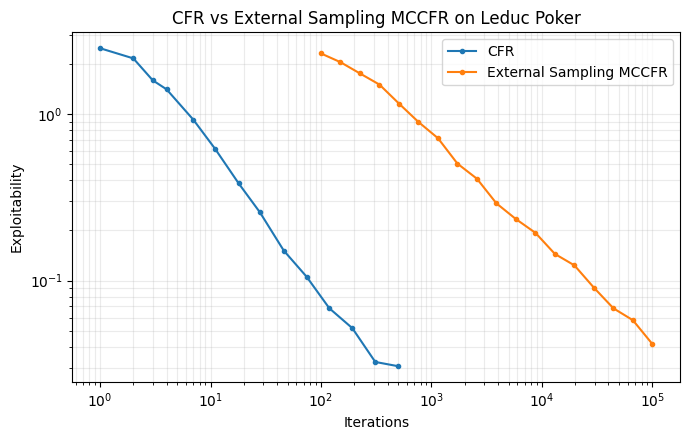

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))

for algorithm, group in summary.groupby("algorithm"):
    group = group.sort_values("iterations")
    ax.plot(group["iterations"], group["exploitability"], marker="o", ms=3, label=algorithm)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Iterations")
ax.set_ylabel("Exploitability")
ax.set_title("CFR vs External Sampling MCCFR on Leduc Poker")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "leduc_cfr_vs_external_sampling_mccfr.png", dpi=200)
plt.show()

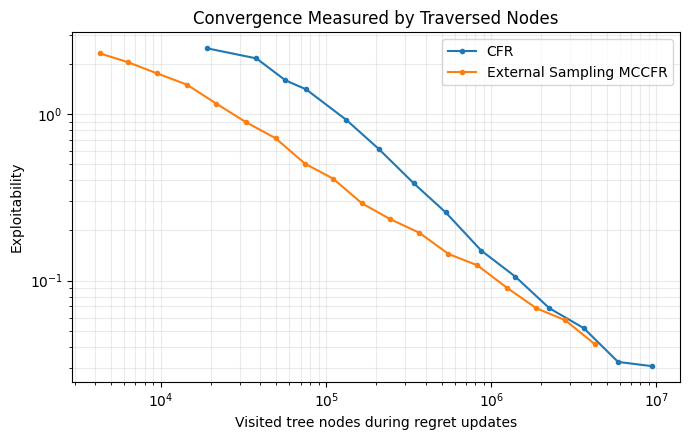

In [7]:
fig, ax = plt.subplots(figsize=(7.0, 4.5))

for algorithm, group in summary.groupby("algorithm"):
    group = group.sort_values("node_visits")
    ax.plot(group["node_visits"], group["exploitability"], marker="o", ms=3, label=algorithm)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Visited tree nodes during regret updates")
ax.set_ylabel("Exploitability")
ax.set_title("Convergence Measured by Traversed Nodes")
ax.grid(True, which="both", alpha=0.25)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "leduc_mccfr_nodes.png", dpi=200)
plt.show()